# Follow gene expression along pseudotime

Pseudotime places cells along an ordering, but the ordering alone does not tell us what
changes along the way. Some genes increase or decrease steadily from progenitor to
terminal population. Others rise briefly and fall again. A correlation score can detect
a steady trend while missing a transient peak with little overall rise or fall.

**Expression dynamics** makes these patterns easier to inspect: we smooth each gene's
expression along the ordering, then group genes with similar profiles into **modules**.
A module might contain genes that fade early, turn on late, or peak in the middle. Here
we use the pancreas analysis to build and interpret those modules.

Start with [](pseudotime.ipynb) for the endpoint choices and scoring method. This page uses
the same ordering and focuses on how to read the expression heatmap.

## Open the prepared analysis and orient its graph

In [1]:
# Load array and table tools alongside the analysis package.
import numpy as np
import pandas as pd

import cytearc

# Keep routine progress messages out of the teaching output.
cytearc.configure_output(level="WARNING", progress=False)

# Download the prepared example, including its saved analysis.
dataset = cytearc.cytebase.connect("cytearc_docs").download_dataset(
    name="bastidas-ponce_4K_pancreas-d15_rnaseq",
    destination="cytearc_datasets",
    zarr=True,
)

Started: 2026-10-08T11:03:10.492936Z | Wall time: 11.152 s

Open the downloaded store and its saved analysis.

In [2]:
# Open the datastore for the following analysis.
ds = cytearc.DataStore(f"{dataset}/data.zarr", nthreads=4)

# Reuse the saved run and its frozen cell selection.
analysis_run = ds.pipeline.open(label="docs_default")

# Keep the graph used by the saved analysis.
graph = analysis_run["connectivity_map"]

# Use the complete feature universe for this assay.
all_features = analysis_run["feature_universe"]

# Inspect the opened assays and their dimensions.
ds

DataStore has 3696 (3696) cells with 1 assays: RNA
   Cell metadata:
            'I', 'ids', 'names', 'G2M_score', 'RNA_UMAP1', 
            'RNA_UMAP2', 'RNA_clusters', 'RNA_leiden_cluster', 'RNA_nCounts', 'RNA_nFeatures', 
            'RNA_percentMito', 'RNA_percentRibo', 'S_score', 'clusters', 'clusters_coarse'
   RNA assay has 27998 features and following metadata:
            'I', 'ids', 'names', 'dropOuts', 'highly_variable_genes', 
            'nCells'

Started: 2026-10-08T11:03:21.651820Z | Wall time: 6.633 s

Use the published cell-type annotations to orient the graph. As in the pseudotime
example, the source and pooled sinks each receive a total mass of one, with opposite signs.

In [3]:
# Read the published cell-type labels for the selected cells.
annotations = ds.cells.fetch("clusters", key="I")

# Mark ductal cells as the source population.
source = annotations == "Ductal"

# Mark the pooled terminal populations.
sink = np.isin(annotations, ["Alpha", "Beta", "Delta"])

# Require at least one annotated source cell and one sink cell.
if not source.any() or not sink.any():
    raise ValueError("Source and sink annotations must both be present")

# Start every graph cell with zero source or sink mass.
source_sink_vector = np.zeros(len(annotations), dtype=float)

# Share total mass -1 among the source cells.
source_sink_vector[source] = -1.0 / source.sum()

# Share total mass +1 among the pooled sink cells.
source_sink_vector[sink] = 1.0 / sink.sum()

# Orient the graph using the chosen source and sinks.
pseudotime_ref = ds.trajectory.pseudotime(graph, ss_vec=source_sink_vector)

# Check how many cells anchor the two ends of the ordering.
pd.Series({"source cells": int(source.sum()), "sink cells": int(sink.sum())})

source cells     916
sink cells      1142
dtype: int64

Started: 2026-10-08T11:03:28.289814Z | Wall time: 1.201 s

## Group changing expression profiles

Start with the default aggregation settings. CyteArc orders cells with valid pseudotime
scores, then smooths each retained gene over a rolling 200-cell window. This replaces
individual, often sparse measurements with a local average along the ordering, making
shared trends easier to see. The smoothed profiles are summarized in 50 ordered bins
with approximately equal cell counts, then grouped into 10 modules. A bin can cover a narrow
or broad range of pseudotime depending on where cells are concentrated. The bins are not
equal intervals of pseudotime or elapsed time.

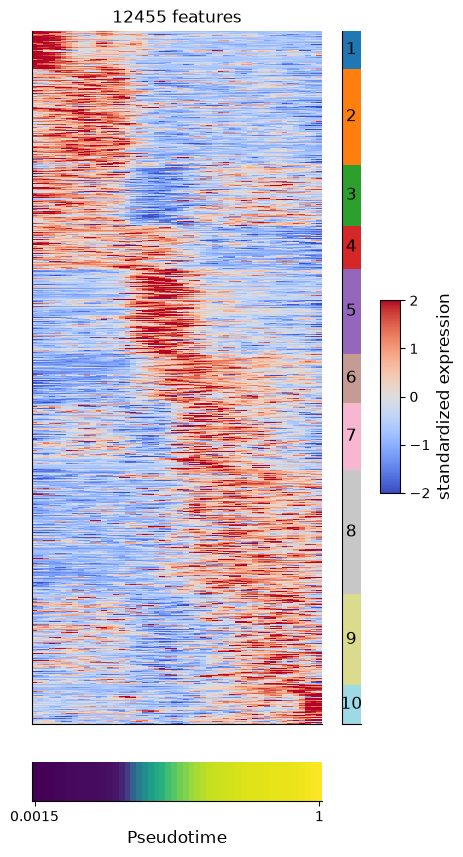

Started: 2026-10-08T11:03:29.494466Z | Wall time: 27.942 s

In [4]:
# Group genes with similar expression profiles along pseudotime.
modules_ref = ds.trajectory.aggregation(pseudotime_ref, features=all_features)

# Display the ordered expression profiles and their modules.
ds.plots.pseudotime_heatmap(aggregation=modules_ref)

Read from early to late pseudotime across the heatmap. Look for groups that peak early,
late, or in the middle. By default, each gene is scaled relative to its own variation.
Red indicates higher expression and blue lower expression for that gene; the colours do
not show which gene has the greatest absolute expression.

Module numbers are labels, not developmental stages. Ten modules is a starting choice,
not a claim that the process has ten biological programs.

## Inspect a module's genes

Load the saved result to see how many genes each module contains:

In [5]:
# Load the saved gene-module assignments.
modules = ds.trajectory.load_aggregation(modules_ref)

# Pair each retained gene with its module label.
module_genes = pd.DataFrame({
    "gene": modules.feature_names,
    "module": modules.feature_clusters,
})

# Count the genes assigned to each expression module.
module_genes.groupby("module").size().rename("genes")

module
1      679
2     1732
3     1092
4      770
5     1537
6      871
7     1213
8     2231
9     1632
10     698
Name: genes, dtype: int64

Started: 2026-10-08T11:03:57.441227Z | Wall time: 0.487 s

Choose a module from the heatmap, then list its genes. The example below selects the
first module label only to show the lookup; the returned genes are not ranked markers.

In [6]:
# Choose the first module to demonstrate gene lookup.
module_id = module_genes["module"].min()

# Inspect the first twenty genes in the chosen module.
module_genes.loc[module_genes["module"] == module_id, "gene"].head(20)

17       Mcm3
26      Prim2
65     Stk17b
70      Hspd1
93      Bard1
137     Usp40
152      Pask
156     Dtymk
183    Zranb3
184      Mcm6
230      Dhx9
231       Npl
252    Klhl20
257      Fmo4
258      Fmo1
274      Nuf2
303       Fh1
319       Lbr
336     Cenpf
345       Dtl
Name: gene, dtype: str

Started: 2026-10-08T11:03:57.931856Z | Wall time: 0.013 s

Check whether several genes support a shared process before naming the module. Follow
up candidate genes with marker maps or other independent evidence.

## Adjust smoothing only when needed

A wide window can hide a brief expression peak; a narrow one can retain more noise.
The width counts cells, not units of time. To explore a shorter window, repeat the call
with one changed setting:

```python
# Group genes with similar expression profiles along pseudotime.
modules_ref = ds.trajectory.aggregation(
    pseudotime_ref, features=all_features, window_size=100
)
```

`n_clusters` controls the requested number of modules and defaults to 10. `chunk_size`
controls the number of displayed pseudotime bins and defaults to 50; it is not a memory
batch size. Change one choice at a time and compare the profiles before interpreting
a split or merged module.

## Common mistakes and limitations

- Expression or variance checks exclude some features; the loaded result contains the
  retained features only.
- **Pooling different lineages can hide their differences.** Alpha, Beta, and Delta cells
  share the pooled sink in this example. Genes specific to one endpoint can appear weak
  when cells from several branches contribute to the same part of the ordering. A shared
  axis does not establish that all cells follow one developmental path.
- **Smoothing changes the patterns you can see.** A broad window can flatten a short
  regulatory pulse, while a narrow one can retain sampling noise. Compare plausible
  endpoint and smoothing choices before treating a module as stable.
- **Relative colour is not absolute abundance or common regulation.** Per-gene scaling
  can make a low-abundance gene look as visually prominent as a highly expressed one.
  Genes with similar curves need not share an upstream regulator, and membership in a
  module does not establish a causal role in the process.

See [](trajectory_validation.md) for checks on orientation, valid cells, and endpoint
sensitivity. [](fate_mapping.ipynb) describes several candidate terminal outcomes for
each cell instead of assigning one position along an axis.